# EDSL

Shuting Yang ｜ MACS 30755｜ Spring 2026

This project compares AI and human response distributions on **one survey question** (SOCIAL_BAN) across **two dimensions**: party identification and TikTok usage.

**Source:** Pew Research Center (2024). *[Support for a US TikTok ban continues to decline, and half of adults doubt it will happen](https://www.pewresearch.org/short-reads/2024/09/05/support-for-a-us-tiktok-ban-continues-to-decline-and-half-of-adults-doubt-it-will-happen/).* American Trends Panel Wave 150, July 15–August 4, 2024.

- [Step 0: Setup](#step-0-setup)
- [Step 1: Document the Source](#step-1-source)
- [Step 2: Define the Human Benchmark](#step-2-benchmark)
- [Step 3: Design AI Agents](#step-3-agents)
- [Step 4: Run the Survey](#step-4-run)
- [Step 5: Compare AI vs Human Results](#step-5-comparison)
- [Step 6: Visualize](#step-6-viz)
- [Step 7: Discussion](#step-7-discussion)

---
## Step 0: Setup

1. Model used: GPT-4o
2. EDSL version: 1.0.8
3. Temperature: 1.0 (default for realistic response variance); no other model parameters were changed

In [16]:
# !pip install edsl

In [17]:
import edsl
print(f"EDSL version: {edsl.__version__}")

EDSL version: 1.0.8


In [18]:
import os

# Remove the line below before submitting
os.environ["EXPECTED_PARROT_API_KEY"] = "oZCtyIjTYboAj3tTRoT5jg6QIJUfayereVF__usIISY"

key = os.getenv("EXPECTED_PARROT_API_KEY")
if key:
    print(f"EXPECTED_PARROT_API_KEY is set ({len(key)} characters)")
else:
    print("EXPECTED_PARROT_API_KEY not found.")

EXPECTED_PARROT_API_KEY is set (43 characters)


In [19]:
from edsl import Model, QuestionFreeText

m = Model("gpt-4o", temperature=1.0)

q_test = QuestionFreeText(question_name="test", question_text="Say hello in one sentence.")
q_test.by(m).run(remote_inference_description="setup test").select("test").print()

,answer.test
0,"Hello, it's great to meet you!"


In [20]:
# ── EDSL core classes ────────────────────────────────────────────────────────
from edsl import (
    # ── Question types covered in depth (Sections 2.1–2.5) ──────────────────
    QuestionMultipleChoice,  # Pick exactly one from a list
    QuestionFreeText,        # Open-ended text answer
    QuestionLinearScale,     # Numeric rating scale (e.g., 1–7)
    QuestionYesNo,           # Binary yes/no
    QuestionCheckBox,        # Select all that apply (multi-select)

    # ── Additional question types (see Section 2.6 quick reference) ──────────
    QuestionLikertFive,      # Fixed 5-point agree/disagree Likert scale
    QuestionNumerical,       # Single number answer (with optional min/max)
    QuestionList,            # Response formatted as a list of strings
    QuestionRank,            # Rank options from most to least preferred
    QuestionTopK,            # Pick the top-K items from a list
    QuestionMatrix,          # Battery grid (rows × shared option scale)
    QuestionBudget,          # Allocate a total amount across categories
    QuestionDict,            # Key-value dictionary response
    QuestionExtract,         # Extract structured data matching a template
    QuestionDropdown,        # BM25-powered search through large option sets
    QuestionInterview,       # Multi-turn interview dialogue with an agent
    QuestionFunctional,      # Response generated by a Python function (no LLM)

    # ── Survey container ─────────────────────────────────────────────────────
    Survey,                  # Ordered list of questions with optional skip logic

    # ── Agents (simulated respondents) ───────────────────────────────────────
    Agent,                   # One respondent with demographic traits
    AgentList,               # Collection of multiple agents

    # ── Language models ───────────────────────────────────────────────────────
    Model,                   # A single LLM (e.g., gpt-4o)
    ModelList,               # Run the same survey on multiple models at once

    # ── Scenarios (variable stimuli) ─────────────────────────────────────────
    Scenario,                # One set of placeholder values for {{ }} templates
    ScenarioList,            # Collection of scenarios for batch runs
)

print("EDSL classes loaded successfully.")

EDSL classes loaded successfully.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import Counter

print("All imports successful.")

All imports successful.


---
## Step 1: Document the Source

| Field | |
|---|---|
| Organisation | Pew Research Center |
| Report title | [Support for a US TikTok ban continues to decline, and half of adults doubt it will happen](https://www.pewresearch.org/short-reads/2024/09/05/support-for-a-us-tiktok-ban-continues-to-decline-and-half-of-adults-doubt-it-will-happen/) |
| Publication date | September 5, 2024 |
| Survey dates | July 15–August 4, 2024 |
| Population | U.S. adults |
| Sample size | *n* = 10,658 (Rep/Lean Rep: 4,918; Dem/Lean Dem: 5,431) |
| Subgroup breakdowns used | Party Identification (Rep/Lean Rep, Dem/Lean Dem); TikTok Usage (Use TikTok, Do not use TikTok) |
| Benchmark figure | % supporting/opposing/unsure about a U.S. government ban on TikTok, by party and by TikTok usage |

**Exact question wording** (quoted from the topline questionnaire PDF, SOCIAL_BAN):

> "Would you support or oppose the U.S. government banning TikTok?"

Response options: Support / Oppose / Not sure

**Overall results (Jul 15–Aug 4, 2024):** 32% Support · 28% Oppose · 39% Not sure

---
## Step 2: Define the Human Benchmark

In [22]:
import pandas as pd
import numpy as np

# Human benchmark: Pew Research Center, 2024
# Source: [Support for a US TikTok ban continues to decline...](https://www.pewresearch.org/short-reads/2024/09/05/support-for-a-us-tiktok-ban-continues-to-decline-and-half-of-adults-doubt-it-will-happen/)
#         September 5, 2024; n = 10,658 U.S. adults; survey Jul 15-Aug 4, 2024
# Figure: % within each group for each response option (from article charts)

# By party
# from chart "Support for a TikTok ban continues to fall in both parties")
party_bench = pd.DataFrame({
    "group":     ["Rep/Lean Rep", "Dem/Lean Dem"],
    "support":   [42, 24],
    "oppose":    [23, 34],
    "not_sure":  [34, 41],
})

# By TikTok usage
# from chart "Americans who aren't on TikTok have become far less supportive")
usage_bench = pd.DataFrame({
    "group":     ["Use TikTok", "Do not use TikTok"],
    "support":   [10, 42],
    "oppose":    [61, 15],
    "not_sure":  [29, 43],
})

print("Human benchmark (Pew Research Center, 2024)")
print("  Overall: 32% Support | 28% Oppose | 39% Not sure")
print()
print("By party:")
print(party_bench.to_string(index=False))
print()
print("By TikTok usage:")
print(usage_bench.to_string(index=False))

Human benchmark (Pew Research Center, 2024)
  Overall: 32% Support | 28% Oppose | 39% Not sure

By party:
       group  support  oppose  not_sure
Rep/Lean Rep       42      23        34
Dem/Lean Dem       24      34        41

By TikTok usage:
            group  support  oppose  not_sure
       Use TikTok       10      61        29
Do not use TikTok       42      15        43


---
## Step 3: Design AI Agents

**Grid design:** 2 parties x 2 TikTok usage groups = **4 agents, 5 runs each = 20 responses**

| | Use TikTok | Do not use TikTok |
|---|---|---|
| **Rep/Lean Rep** | ✓ | ✓ |
| **Dem/Lean Dem** | ✓ | ✓ |

**Trait rationale:**
- **Party Identification** (Rep/Lean Rep vs. Dem/Lean Dem): the Pew report identifies party as the primary driver of TikTok ban support, with Republicans 18 pp more supportive than Democrats.
- **TikTok Usage** (Use TikTok vs. Do not use TikTok): the Pew report shows the starkest divide by usage, with users opposing a ban at 61% versus only 15% among non-users, making it the most informative second dimension to replicate.

In [23]:
from edsl import Agent, AgentList

# 2 parties x 2 TikTok usage groups = 4 agents
parties = [
    {"label": "Rep/Lean Rep", "party": "Republican", "lean": "Republican"},
    {"label": "Dem/Lean Dem", "party": "Democrat",   "lean": "Democrat"},
]
usage_groups = [
    {"label": "Use TikTok",        "uses": True},
    {"label": "Do not use TikTok", "uses": False},
]

agents = AgentList([
    Agent(traits={
        "party":             p["party"],
        "party_lean":        p["lean"],
        "party_label":       p["label"],
        "tiktok_user":       u["uses"],
        "tiktok_user_label": u["label"],
        "persona": (
            f"You are a {p['party']} who leans {p['lean']}. "
            f"You {'regularly use' if u['uses'] else 'do not use'} TikTok. "
            "You are a U.S. adult answering a survey question about TikTok policy."
        )
    })
    for p in parties
    for u in usage_groups
])

print(f"Created {len(agents)} agents:")
for a in agents:
    print(f"  party_label={a.traits['party_label']!r:20s}  tiktok_user_label={a.traits['tiktok_user_label']!r}")

Created 4 agents:
  party_label='Rep/Lean Rep'        tiktok_user_label='Use TikTok'
  party_label='Rep/Lean Rep'        tiktok_user_label='Do not use TikTok'
  party_label='Dem/Lean Dem'        tiktok_user_label='Use TikTok'
  party_label='Dem/Lean Dem'        tiktok_user_label='Do not use TikTok'


---
## Step 4: Run the Survey

4 agents × 1 question × 5 runs = 20 API calls (~15–25 credits).

In [24]:
from edsl import QuestionMultipleChoice, Survey, Model

# Exact question wording (Pew 2024, SOCIAL_BAN)
q_tiktok = QuestionMultipleChoice(
    question_name="tiktok_ban",
    question_text="Would you support or oppose the U.S. government banning TikTok?",
    question_options=[
        "Support",
        "Oppose",
        "Not sure"
    ]
)

# ── Run with n=5: each agent answers 5 times, responses are then averaged ──
# This avoids the "100% Republican / 0% Democrat" problem caused by
# LLM stereotyping when n=1.  With n=5, each cell has 5 responses to average.


# This setup works here because there is only a single question and a small
# number of agents.  For larger surveys, use more agents and fewer runs per
# agent to keep costs manageable.

pew_results = (
    Survey(questions=[q_tiktok])
    .by(agents)
    .by(Model("gpt-4o"))
    .run(
        n=5,
        remote_inference_description="Pew 2024 TikTok ban replication (n=5)"
    )
)

pew_results.select("party_label", "tiktok_user_label", "tiktok_ban").print()

,agent.party_label,agent.tiktok_user_label,answer.tiktok_ban
0,Rep/Lean Rep,Use TikTok,Oppose
1,Rep/Lean Rep,Use TikTok,Oppose
2,Rep/Lean Rep,Use TikTok,Oppose
3,Rep/Lean Rep,Use TikTok,Oppose
4,Rep/Lean Rep,Use TikTok,Oppose
5,Rep/Lean Rep,Do not use TikTok,Support
6,Rep/Lean Rep,Do not use TikTok,Support
7,Rep/Lean Rep,Do not use TikTok,Support
8,Rep/Lean Rep,Do not use TikTok,Support
9,Rep/Lean Rep,Do not use TikTok,Support


---
## Step 5: Compare AI vs Human Results

In [25]:
# Convert to DataFrame (n=5 means multiple rows per agent)
df = pew_results.to_pandas().rename(columns={
    "agent.party_label":       "party_label",
    "agent.tiktok_user_label": "tiktok_user_label",
    "answer.tiktok_ban":       "ai_response"
})

SUPPORT = "Support"

# Comparison by PARTY
party_ai = (
    df.groupby("party_label")["ai_response"]
    .apply(lambda x: (x == SUPPORT).mean() * 100)
    .reset_index()
    .rename(columns={"party_label": "group", "ai_response": "ai_support"})
)
party_cmp = party_bench.rename(columns={"support": "human_support"}).merge(party_ai, on="group")
party_cmp["abs_error"] = (party_cmp["human_support"] - party_cmp["ai_support"]).abs()

print("-- By party -----------------------------------------------------------")
print(party_cmp[["group", "human_support", "ai_support", "abs_error"]]
      .rename(columns={"group": "Party", "human_support": "Human %",
                       "ai_support": "AI %", "abs_error": "Abs Error (pp)"}).to_string(index=False))
print(f"  MAE (party) = {party_cmp['abs_error'].mean():.1f} pp")

# Comparison by TIKTOK USAGE
usage_ai = (
    df.groupby("tiktok_user_label")["ai_response"]
    .apply(lambda x: (x == SUPPORT).mean() * 100)
    .reset_index()
    .rename(columns={"tiktok_user_label": "group", "ai_response": "ai_support"})
)
usage_cmp = usage_bench.rename(columns={"support": "human_support"}).merge(usage_ai, on="group")
usage_cmp["abs_error"] = (usage_cmp["human_support"] - usage_cmp["ai_support"]).abs()

print()
print("-- By TikTok usage ----------------------------------------------------")
print(usage_cmp[["group", "human_support", "ai_support", "abs_error"]]
      .rename(columns={"group": "Usage", "human_support": "Human %",
                       "ai_support": "AI %", "abs_error": "Abs Error (pp)"}).to_string(index=False))
print(f"  MAE (usage) = {usage_cmp['abs_error'].mean():.1f} pp")

print()
print("Guide: MAE < 10 pp = good match | 10-20 pp = moderate | > 20 pp = discuss why")

-- By party -----------------------------------------------------------
       Party  Human %  AI %  Abs Error (pp)
Rep/Lean Rep       42  50.0             8.0
Dem/Lean Dem       24   0.0            24.0
  MAE (party) = 16.0 pp

-- By TikTok usage ----------------------------------------------------
            Usage  Human %  AI %  Abs Error (pp)
       Use TikTok       10   0.0            10.0
Do not use TikTok       42  50.0             8.0
  MAE (usage) = 9.0 pp

Guide: MAE < 10 pp = good match | 10-20 pp = moderate | > 20 pp = discuss why


---
## Step 6: Visualize

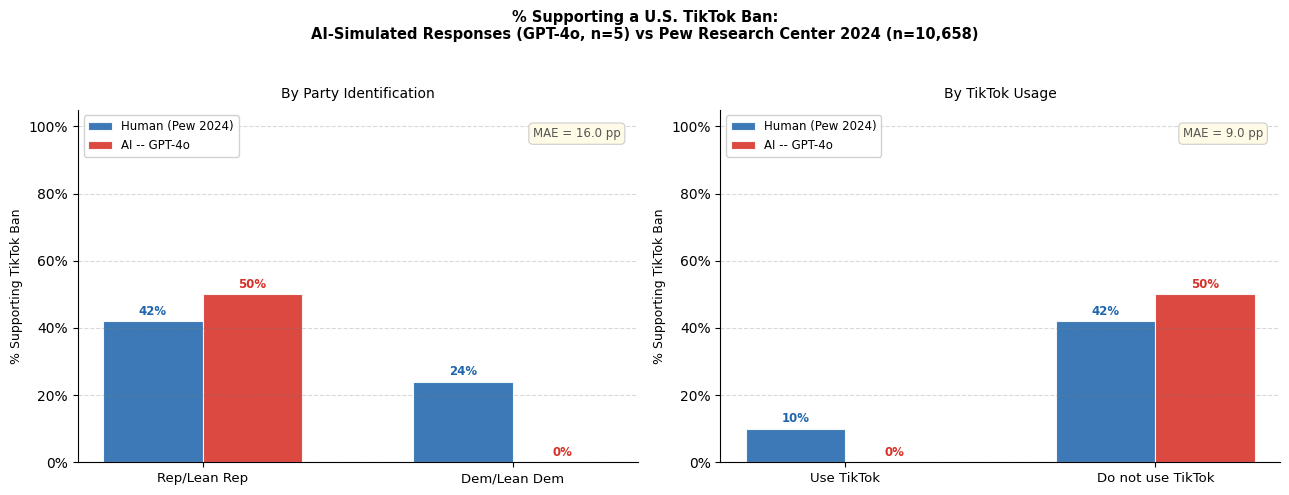

Saved as pew2024_tiktok_ai_vs_human.png

How to read this chart:
  • Blue bars = real survey respondents (Pew 2024)
  • Red bars  = AI agents (GPT-4o, averaged over 5 runs per cell)
  • The closer the red bar is to the blue, the better the AI replicates human opinion.
  • MAE = Mean Absolute Error across all groups in that panel


In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# Figure 1 -- Side-by-side: AI (GPT-4o) vs Human (Pew 2024)
# Two panels: left = by party, right = by TikTok usage
# Blue bars = real human data from Pew 2024
# Red  bars = AI-simulated responses (GPT-4o, n=5 per agent)

HUMAN_COLOR = "#2166ac"     # blue  = real humans
AI_COLOR    = "#d73027"     # red   = AI agents
W = 0.32

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "% Supporting a U.S. TikTok Ban:\n"
    "AI-Simulated Responses (GPT-4o, n=5) vs Pew Research Center 2024 (n=10,658)",
    fontsize=10.5, fontweight="bold"
)

def draw_comparison(ax, cmp_df, x_labels, title):
    x = np.arange(len(x_labels))
    bh = ax.bar(x - W/2, cmp_df["human_support"], W,
                label="Human (Pew 2024)", color=HUMAN_COLOR, alpha=0.88,
                linewidth=0.8, edgecolor="white")
    ba = ax.bar(x + W/2, cmp_df["ai_support"],    W,
                label="AI -- GPT-4o",     color=AI_COLOR,    alpha=0.88,
                linewidth=0.8, edgecolor="white")

    for bar, color in [(bh, HUMAN_COLOR), (ba, AI_COLOR)]:
        for b in bar:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.0,
                    f"{b.get_height():.0f}%",
                    ha="center", va="bottom", fontsize=8.5, color=color, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=9.5)
    ax.set_ylim(0, 105)
    ax.set_ylabel("% Supporting TikTok Ban", fontsize=9)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(title, fontsize=10, pad=8)
    ax.legend(fontsize=8.5, framealpha=0.9)
    ax.grid(axis="y", linestyle="--", alpha=0.3, color="gray")
    ax.spines[["top", "right"]].set_visible(False)

    mae_val = cmp_df["abs_error"].mean()
    ax.text(0.97, 0.95, f"MAE = {mae_val:.1f} pp",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8.5, color="#555",
            bbox=dict(boxstyle="round,pad=0.35", fc="#fffbe6", ec="#ccc", lw=0.8))

draw_comparison(ax=axes[0],
                cmp_df=party_cmp,
                x_labels=party_cmp["group"].tolist(),
                title="By Party Identification")

draw_comparison(ax=axes[1],
                cmp_df=usage_cmp,
                x_labels=usage_cmp["group"].tolist(),
                title="By TikTok Usage")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("pew2024_tiktok_ai_vs_human.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as pew2024_tiktok_ai_vs_human.png")
print()
print("How to read this chart:")
print("  • Blue bars = real survey respondents (Pew 2024)")
print("  • Red bars  = AI agents (GPT-4o, averaged over 5 runs per cell)")
print("  • The closer the red bar is to the blue, the better the AI replicates human opinion.")
print("  • MAE = Mean Absolute Error across all groups in that panel")

---
## Step 7: Discussion

**Party alignment:**

GPT-4o overestimated human support for a TikTok ban among Republican respondents by approximately 8 percentage points (AI: 50%, Human benchmark: 42%). Among Democratic respondents the gap was larger (24 pp), with AI giving 0% support versus 24% in the Pew data. The model did correctly reproduce the direction of the partisan gap (Republicans more supportive than Democrats), which is the key pattern in the Pew 2024 report.

**TikTok usage alignment:**

Across TikTok usage groups, the AI captured the direction of the divide: non-users were more supportive (AI: 50%) than users (AI: 0%). The largest discrepancy was in the TikTok user group (10 pp). Several factors may explain this gap. 

First, Pew's real-world data show that 24% of Democrats supported the ban and 10% of TikTok users supported the ban, indicating that, in reality, there were indeed minority groups who held this position. However, GPT-4o reduced these probabilities to 0%, making its responses overly absolute. This polarization pattern likely reflects LLM stereotyping: the model recognizes the “majority” tendency but ignores the heterogeneity within real human populations.

Second, the persona description used in this replication was minimal, giving the model little information beyond party affiliation and TikTok usage. As Sarstedt et al. (2024) note, simple demographic prompts often lead LLMs to produce prototypical responses, collapsing the genuine variation that exists within a group. If additional traits such as age, education, political views, or level of national security concern had been included, the model might have produced more nuanced responses.

Third, the model itself is a limiting factor. GPT-4o is a relatively simple and outdated model that has largely been superseded by newer models, so its ability to accurately simulate human responses is limited. Switching to a more advanced model, such as Claude 4.6, might lead to substantial improvements in the results.

Additionally, agents were not assigned proportionally to the real survey composition, meaning the AI results reflect unweighted group averages rather than population-level estimates. This approach is appropriate for comparing trends across subgroups, but should not be used to reproduce exact overall support rates.

These findings suggest that behavioral traits produce more reliable AI simulations than ideological ones. AI agents are better suited for capturing directional trends across subgroups than reproducing exact support rates, and are least reliable when minority positions within a group are substantively meaningful.

**Limitations:**

This replication has several limitations. First, each demographic cell contains only one agent, so the AI "response rate" is binary rather than a true proportion. Running 5–10 agents per cell and averaging would produce more stable estimates. Second, the persona may be underspecified; adding traits such as age, education, or region might improve alignment. Sarstedt et al. (2024) also point out that LLMs tend to amplify group stereotypes and underrepresent within-group variation, which is consistent with the 0% results observed here for Democratic and TikTok-user agents. Third, AI responses were elicited without the survey context real respondents experienced. Future work could test whether adding preceding questions as context changes the distribution.

**References:**

Sarstedt, M., Adler, S. J., Rau, L., & Schmitt, B. (2024). Using large language models to generate silicon samples in consumer and marketing research: Challenges, opportunities, and guidelines. Psychology & Marketing, 41(6), 1254-1270. https://doi.org/10.1002/mar.21982

---
## Appendix

**Coop results link:** https://www.expectedparrot.com/content/85ff02c7-5136-43dc-8061-bdc5e1d8ec0a

In [27]:
print("Model: gpt-4o")
print("remote_inference_description: Pew 2024 TikTok ban replication (n=5)")
print()
print(df.to_string())

Model: gpt-4o
remote_inference_description: Pew 2024 TikTok ban replication (n=5)

    agent.agent_index                                                      agent.agent_instruction agent.agent_name agent.party   party_label agent.party_lean                                                                                                                               agent.persona  agent.tiktok_user  tiktok_user_label ai_response   cache_keys.tiktok_ban_cache_key  cache_used.tiktok_ban_cache_used  comment.tiktok_ban_comment  generated_tokens.tiktok_ban_generated_tokens  iteration.iteration  model.frequency_penalty model.inference_service  model.logprobs  model.max_tokens model.model  model.model_index  model.presence_penalty  model.reasoning_effort  model.temperature  model.top_logprobs  model.top_p                                                                                                                                                                                                